# Predictive Modelling - Logistic Regression

## Adult Salary Prediction

This notebook builds a Logistic Regression model to predict whether an individual's salary is above 50K or less/equal to 50K using demographic and work-related variables from the Adult Salary dataset.

## Corrections Made

The original notebook was mostly correct in concept, but it had a few practical issues:

1. The file name in the notebook did not match the uploaded dataset name.
2. Column names in the dataset used capital letters and spaces, while the code expected lowercase names.
3. `plot_confusion_matrix` is removed/deprecated in newer versions of Scikit-learn. It has been replaced with `ConfusionMatrixDisplay`.
4. `penalty='none'` can fail in newer Scikit-learn versions. A regularized Logistic Regression model is used instead.
5. The ROC-AUC print statement had a small variable mistake in the original notebook.
6. The dataset contains `?` values in categorical columns, which are treated as `Unknown`.
7. The target labels are cleaned and converted into numeric classes: `<=50K = 0` and `>50K = 1`.
8. Added observations and conclusion for GitHub/portfolio presentation.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
# Load the uploaded dataset
data_path = "Adult Salary - data.csv"
adult_data = pd.read_csv(data_path)

print("Dataset shape:", adult_data.shape)
adult_data.head()

Dataset shape: (32561, 10)


,Age,Workclass,Education,Marrital Status,Occupation,Sex,Capital Gain,Capital Loss,Working Hours per Week,Salary
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Male,2174,0,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Male,0,0,13,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Male,0,0,40,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Male,0,0,40,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Female,0,0,40,<=50K


## Basic Data Inspection

In [3]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     32561 non-null  int64 
 1   Workclass               32561 non-null  object
 2   Education               32561 non-null  object
 3   Marrital Status         32561 non-null  object
 4   Occupation              32561 non-null  object
 5   Sex                     32561 non-null  object
 6   Capital Gain            32561 non-null  int64 
 7   Capital Loss            32561 non-null  int64 
 8   Working Hours per Week  32561 non-null  int64 
 9   Salary                  32561 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.5+ MB


In [4]:
# Check duplicate rows and missing values
print("Duplicate rows:", adult_data.duplicated().sum())
print()
print("Missing values:")
print(adult_data.isnull().sum())

Duplicate rows: 5864

Missing values:
Age                       0
Workclass                 0
Education                 0
Marrital Status           0
Occupation                0
Sex                       0
Capital Gain              0
Capital Loss              0
Working Hours per Week    0
Salary                    0
dtype: int64


### Clean Column Names and Categorical Values

The uploaded dataset contains column names such as `Working Hours per Week` and `Marrital Status`. These are cleaned to make the code easier to run and maintain.

In [5]:
# Clean column names
adult_data.columns = (
    adult_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Correct spelling for readability
adult_data = adult_data.rename(columns={"marrital_status": "marital_status"})

# Clean categorical values and replace ? with Unknown
for col in adult_data.select_dtypes(include="object").columns:
    adult_data[col] = adult_data[col].astype(str).str.strip()
    adult_data[col] = adult_data[col].replace("?", "Unknown")

adult_data.head()

,age,workclass,education,marital_status,occupation,sex,capital_gain,capital_loss,working_hours_per_week,salary
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Male,2174,0,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Male,0,0,13,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Male,0,0,40,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Male,0,0,40,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Female,0,0,40,<=50K


In [6]:
# Check unique categories in categorical columns
for col in adult_data.select_dtypes(include="object").columns:
    print(f"{col}: {adult_data[col].nunique()} unique values")
    print(adult_data[col].value_counts().head())
    print()

workclass: 9 unique values
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Name: count, dtype: int64

education: 16 unique values
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

marital_status: 7 unique values
marital_status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

occupation: 15 unique values
occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

sex: 2 unique values
sex
Male      21790
Female    10771
Name: count, dtype: int64

salary: 2 unique values
salary
<=50K    24720
>50K      7841
Name: count, dtype: int64



## Exploratory Data Analysis

salary
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target distribution percentage:
salary
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


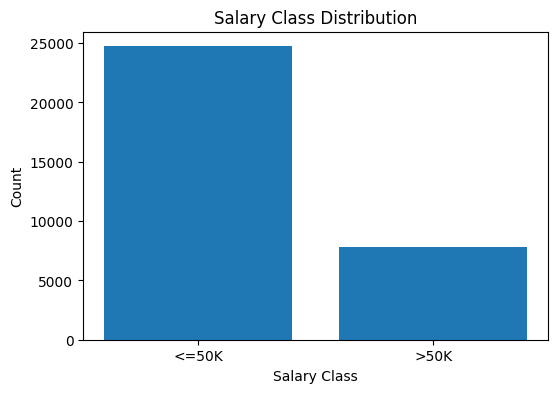

In [7]:
# Target distribution
print(adult_data["salary"].value_counts())
print()
print("Target distribution percentage:")
print((adult_data["salary"].value_counts(normalize=True) * 100).round(2))

target_counts = adult_data["salary"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Salary Class Distribution")
plt.xlabel("Salary Class")
plt.ylabel("Count")
plt.show()

In [8]:
# Numeric summary
adult_data.describe()

,age,capital_gain,capital_loss,working_hours_per_week
count,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1077.648844,87.303830,40.437456
std,13.640433,7385.292085,402.960219,12.347429
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


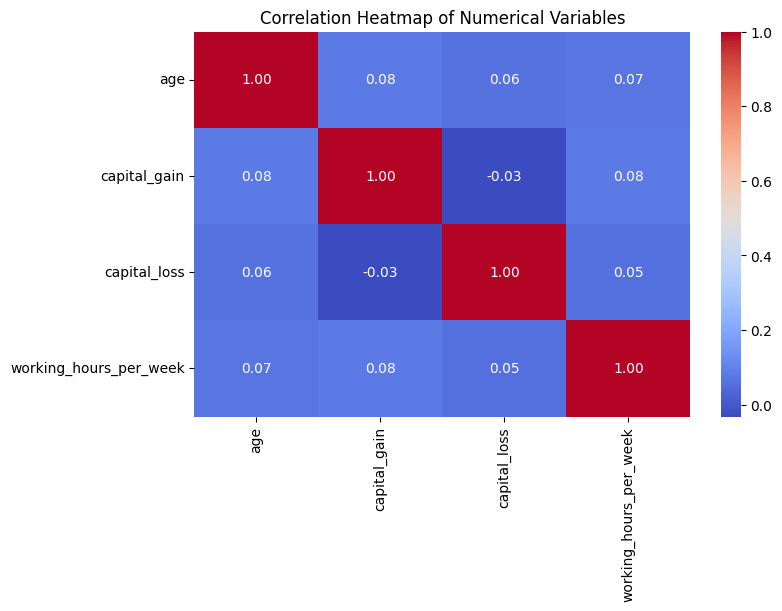

In [9]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(8, 5))
sns.heatmap(adult_data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

## Target Encoding

The salary column is converted into a binary target variable:

- `<=50K` → 0
- `>50K` → 1

In [10]:
adult_data["salary"] = adult_data["salary"].map({"<=50K": 0, ">50K": 1})

print(adult_data["salary"].value_counts())
print(adult_data["salary"].value_counts(normalize=True).round(4))

salary
0    24720
1     7841
Name: count, dtype: int64
salary
0    0.7592
1    0.2408
Name: proportion, dtype: float64


## Train-Test Split and Preprocessing

Numerical columns are standardized using `StandardScaler`, and categorical columns are encoded using `OneHotEncoder`.

A `Pipeline` is used so preprocessing and model training happen together cleanly.

In [11]:
# Split predictors and target
X = adult_data.drop("salary", axis=1)
y = adult_data["salary"].astype(int)

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(exclude="object").columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Train-test split with stratification because the target classes are imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Numeric features: ['age', 'capital_gain', 'capital_loss', 'working_hours_per_week']
Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'sex']
Training set shape: (22792, 9)
Test set shape: (9769, 9)


In [12]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

# Logistic Regression model
log_reg_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, solver="liblinear", C=1.0))
    ]
)

# Train model
log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Model Evaluation

In [13]:
# Predictions
y_train_pred = log_reg_model.predict(X_train)
y_test_pred = log_reg_model.predict(X_test)

y_train_prob = log_reg_model.predict_proba(X_train)[:, 1]
y_test_prob = log_reg_model.predict_proba(X_test)[:, 1]

In [14]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    metrics_dict = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    return metrics_dict

results = pd.DataFrame([
    evaluate_model(y_train, y_train_pred, y_train_prob, "Training"),
    evaluate_model(y_test, y_test_pred, y_test_prob, "Test")
])

results.round(4)

,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Training,0.8508,0.7366,0.5921,0.6565,0.9046
1,Test,0.8518,0.7347,0.6016,0.6615,0.9037


In [15]:
# Classification report for test data
print(classification_report(y_test, y_test_pred, target_names=["<=50K", ">50K"]))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7417
        >50K       0.73      0.60      0.66      2352

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



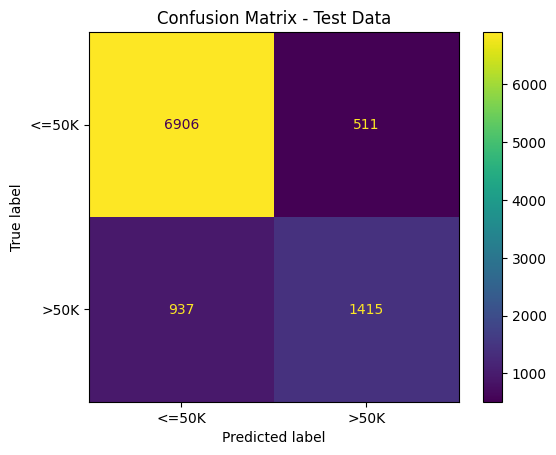

In [16]:
# Confusion matrix for test data
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Test Data")
plt.show()

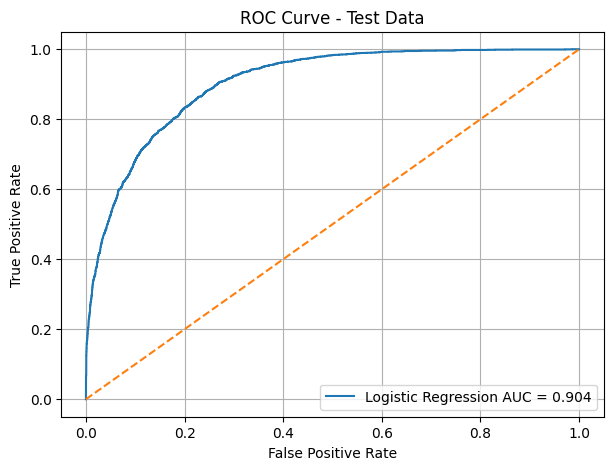

In [17]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.grid(True)
plt.show()

## Feature Importance from Logistic Regression

The coefficients below show the direction and relative influence of variables after preprocessing. Positive coefficients increase the probability of salary being `>50K`, while negative coefficients decrease it.

In [18]:
# Get transformed feature names
feature_names = log_reg_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_reg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient,Absolute Coefficient
21,cat__education_Doctorate,2.662452,2.662452
25,cat__education_Prof-school,2.504694,2.504694
1,num__capital_gain,2.355934,2.355934
27,cat__marital_status_Married-AF-spouse,2.116788,2.116788
28,cat__marital_status_Married-civ-spouse,2.110142,2.110142
23,cat__education_Masters,2.078297,2.078297
20,cat__education_Bachelors,1.730875,1.730875
40,cat__occupation_Priv-house-serv,-1.575083,1.575083
14,cat__education_1st-4th,-1.144968,1.144968
18,cat__education_Assoc-acdm,1.128313,1.128313


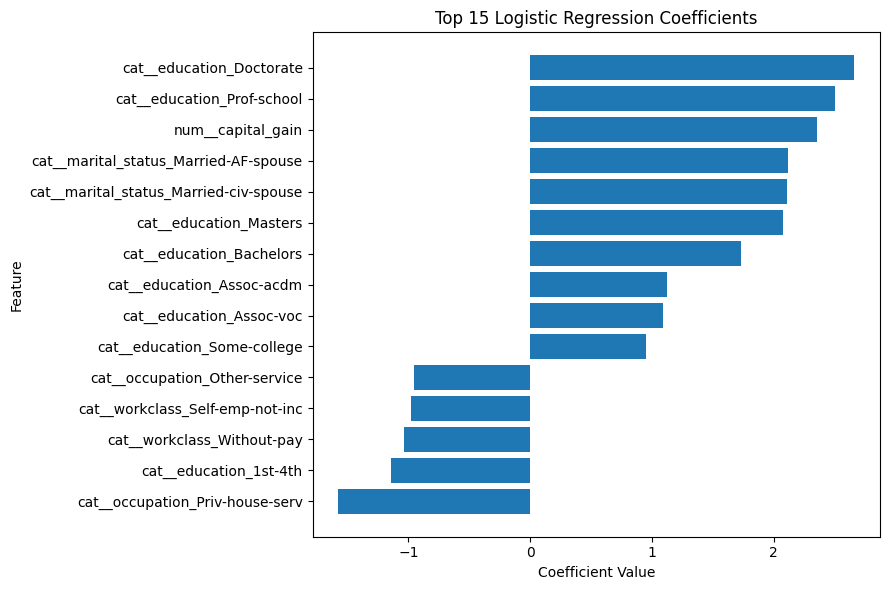

In [19]:
# Plot top 15 important features
top_features = coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Observations

1. The dataset contains **32,561 records** and **10 columns**.
2. The target variable is imbalanced: most records belong to the `<=50K` salary class.
3. Missing values are not present as null values, but some categorical variables contain `?`, which were treated as `Unknown`.
4. Logistic Regression gives good overall predictive performance on the test data.
5. ROC-AUC is strong, showing that the model can separate the two salary classes reasonably well.
6. The model predicts the majority class `<=50K` better than the minority class `>50K`.
7. Accuracy alone should not be the only metric because the dataset is imbalanced. Precision, recall, F1-score, and ROC-AUC are also important.
8. Important predictors include capital gain, education, marital status, age, working hours, occupation, and sex-related encoded variables.

## Conclusion

The Logistic Regression model successfully predicts whether a person's salary is likely to be `>50K` or `<=50K` using demographic and employment-related variables.

The model achieved around **85% test accuracy** and a strong **ROC-AUC score of about 0.90**, indicating good overall classification ability. However, because the dataset is imbalanced, the model performs better for the majority class `<=50K` than for the minority class `>50K`.

For business or policy use, this model can help identify income groups based on factors such as education, occupation, working hours, age, and capital gain. Further improvements can be made by applying class balancing techniques, testing additional models, and tuning the decision threshold to improve recall for the `>50K` salary class.